## IMPORT LIBRARY

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

import tensorflow as tf
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout, Flatten, Input
from tensorflow.keras.applications import ResNet152, DenseNet121, VGG19, MobileNetV2

from tensorflow.keras.applications.vgg19 import preprocess_input as prep_VGG19
from tensorflow.keras.applications.resnet import preprocess_input as prep_ResNet152
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as prep_MobileNetV2
from tensorflow.keras.applications.densenet import preprocess_input as prep_DenseNet121


import shutil
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

## SPLIT DATA

In [ ]:
source_dir = "Rice_Leaf_Diease"
target_dir = "dataset_70_15_15"

train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15
random_seed = 42

random.seed(random_seed)

selected_classes = [
    "bacterial_leaf_blight", "brown_spot", "healthy", "leaf_blast", "leaf_scald",
    "narrow_brown_spot", "neck_blast", "rice_hispa", "sheath_blight", "tungro"
]

max_samples  = 1000

splits = ["train", "test"]

if os.path.exists(target_dir):
    print(f"Folder {target_dir} sudah ada, Langkah ini bisa dilewatkan")

else:
    for cls in selected_classes:
        files = []

        # ambil dari train + test lama
        for split in splits:
            cls_path = os.path.join(source_dir, split, cls)
            if not os.path.exists(cls_path):
                continue

            for f in os.listdir(cls_path):
                files.append(os.path.join(cls_path, f))

        if len(files) == 0:
            raise ValueError(f"Kelas {cls} tidak memiliki data!")

        random.shuffle(files)

        if len(files) < max_samples:
            raise ValueError(
                f"Data kelas {cls} hanya {len(files)}, kurang dari {max_samples}"
            )

        files = files[:max_samples]

        # split 70 / 15 / 15
        train_files, temp_files = train_test_split(
            files,
            test_size=(val_ratio + test_ratio),
            random_state=random_seed
        )

        val_files, test_files = train_test_split(
            temp_files,
            test_size=test_ratio / (val_ratio + test_ratio),
            random_state=random_seed
        )

        # buat folder target
        for split_name in ["train", "val", "test"]:
            os.makedirs(
                os.path.join(target_dir, split_name, cls),
                exist_ok=True
            )

        # fungsi copy
        def copy_files(file_list, split_name):
            for i, file in enumerate(file_list):
                new_name = f"{cls}_{i}_{os.path.basename(file)}"
                shutil.copy(
                    file,
                    os.path.join(target_dir, split_name, cls, new_name)
                )

        copy_files(train_files, "train")
        copy_files(val_files, "val")
        copy_files(test_files, "test")

        print(
            f"{cls}: total={len(files)} | "
            f"train={len(train_files)}, "
            f"val={len(val_files)}, "
            f"test={len(test_files)}"
        )

    print("\n✅ Dataset 70/15/15 dengan batas per kelas berhasil dibuat")

Folder dataset_70_15_15 sudah ada, Langkah ini bisa dilewatkan


In [3]:
train_dir = "dataset_70_15_15/train"
val_dir = "dataset_70_15_15/val"
test_dir = "dataset_70_15_15/test"

In [4]:
# Function to count number of images in each class
def count_images_in_class(directory):
  class_counts = {}
  for class_name in os.listdir(directory):
    class_dir = os.path.join(directory, class_name)
    if os.path.isdir(class_dir):
      class_counts[class_name] = len(os.listdir(class_dir))
  return class_counts

print("Counts in train directory:")
train_counts = count_images_in_class(train_dir)
for class_name, count in train_counts.items():
  print(f"{class_name}: {count}")

print("\nCounts in validation directory:")
val_counts = count_images_in_class(val_dir)
for class_name, count in val_counts.items():
  print(f"{class_name}: {count}")

print("\nCounts in test directory:")
test_counts = count_images_in_class(test_dir)
for class_name, count in test_counts.items():
  print(f"{class_name}: {count}")

Counts in train directory:
bacterial_leaf_blight: 700
brown_spot: 700
healthy: 700
leaf_blast: 700
leaf_scald: 700
narrow_brown_spot: 700
neck_blast: 700
rice_hispa: 700
sheath_blight: 700
tungro: 700

Counts in validation directory:
bacterial_leaf_blight: 150
brown_spot: 150
healthy: 150
leaf_blast: 150
leaf_scald: 150
narrow_brown_spot: 150
neck_blast: 150
rice_hispa: 150
sheath_blight: 150
tungro: 150

Counts in test directory:
bacterial_leaf_blight: 150
brown_spot: 150
healthy: 150
leaf_blast: 150
leaf_scald: 150
narrow_brown_spot: 150
neck_blast: 150
rice_hispa: 150
sheath_blight: 150
tungro: 150


In [5]:
data = pd.DataFrame({
    'train': pd.Series(train_counts),
    'validation': pd.Series(val_counts),
    'test': pd.Series(test_counts)
})

print("\nCounts in a single DataFrame:")
data


Counts in a single DataFrame:


,train,validation,test
bacterial_leaf_blight,700,150,150
brown_spot,700,150,150
healthy,700,150,150
leaf_blast,700,150,150
leaf_scald,700,150,150
narrow_brown_spot,700,150,150
neck_blast,700,150,150
rice_hispa,700,150,150
sheath_blight,700,150,150
tungro,700,150,150


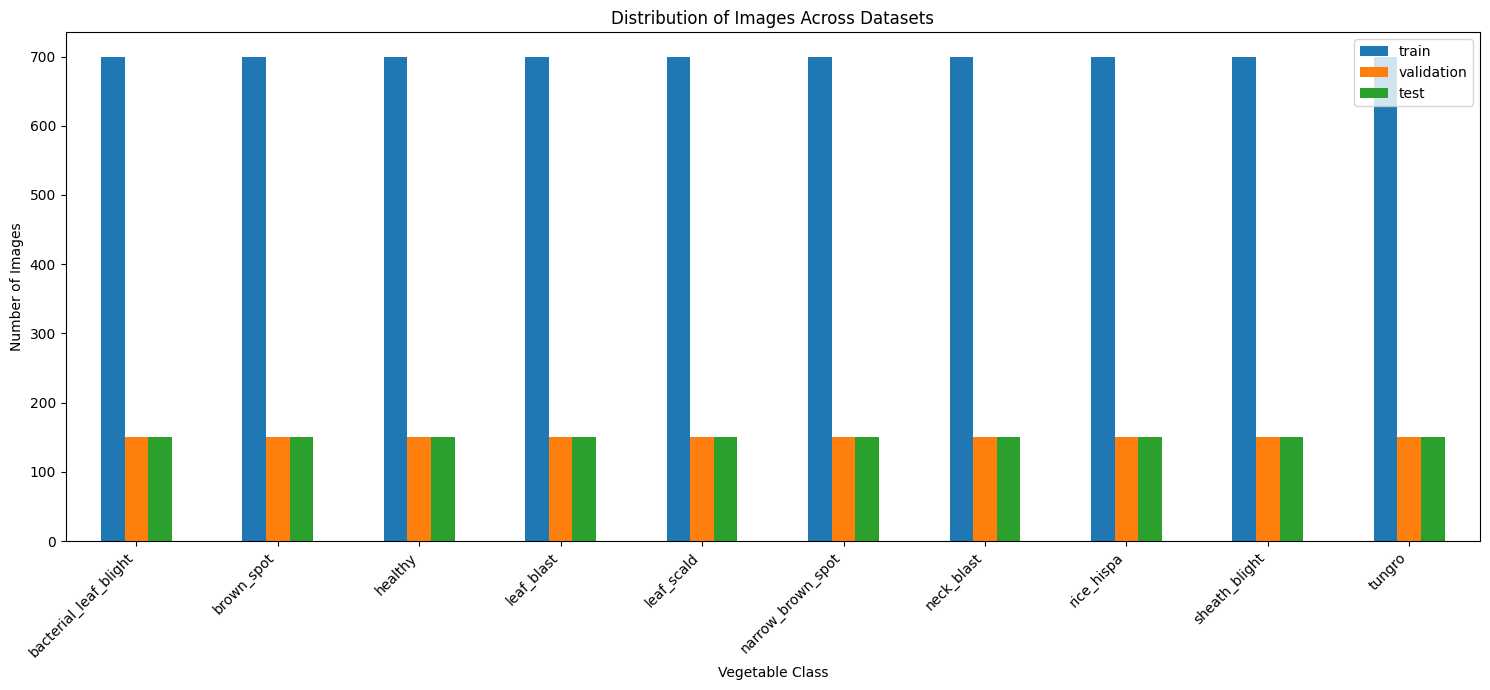

In [6]:
data.plot(kind='bar', figsize=(15, 7))
plt.title('Distribution of Images Across Datasets')
plt.xlabel('Vegetable Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Jumlah kelas: 10


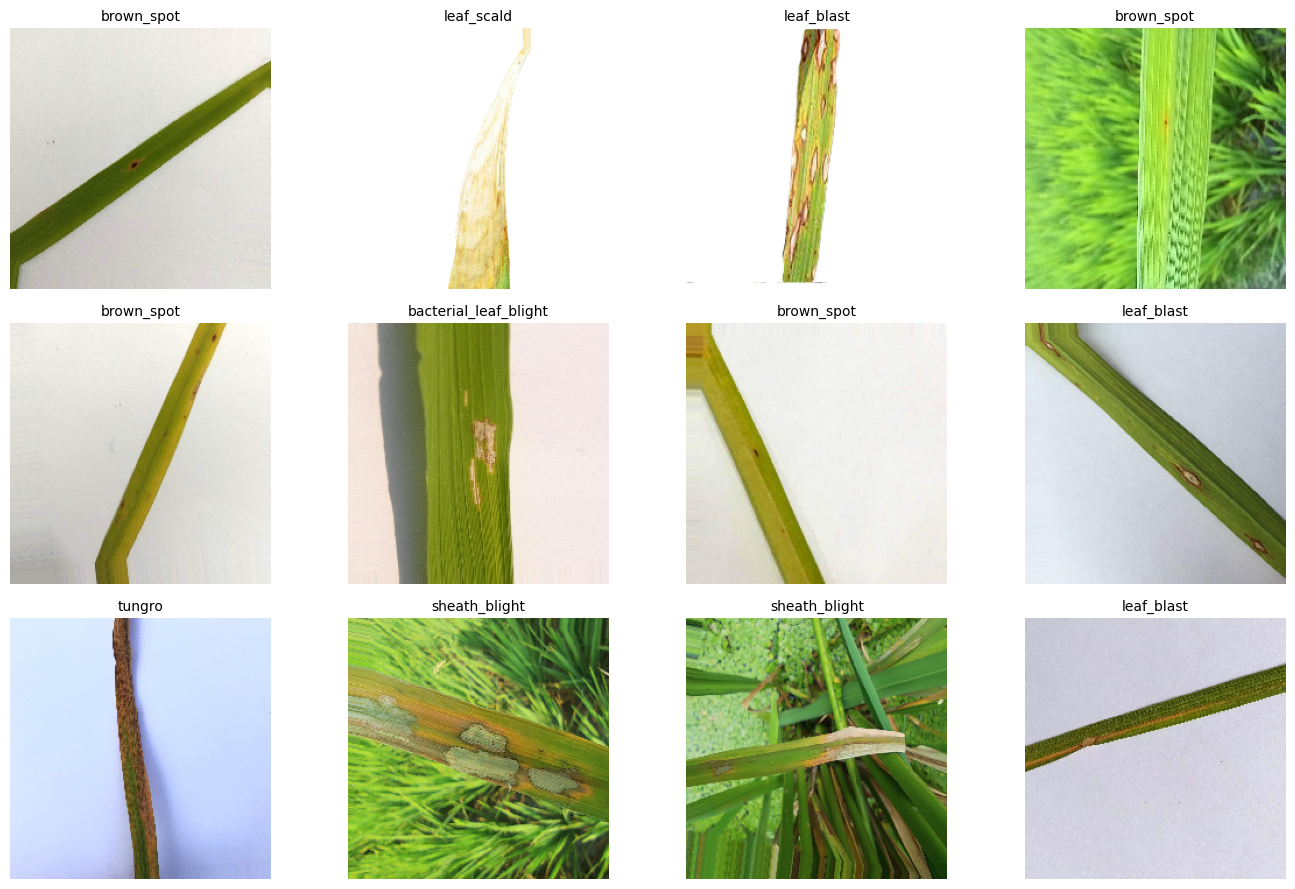

In [7]:
import os
import random
import matplotlib.pyplot as plt


IMG_SIZE = (224, 224)
TOTAL_IMAGES = 12   # total gambar yang ingin ditampilkan

# =====================
# Ambil semua kelas
# =====================
class_names = [
    cls for cls in os.listdir(test_dir)
    if os.path.isdir(os.path.join(test_dir, cls))
]

print("Jumlah kelas:", len(class_names))

# =====================
# Ambil gambar acak dari berbagai kelas
# =====================
images = []
labels = []

while len(images) < TOTAL_IMAGES:
    cls = random.choice(class_names)
    cls_dir = os.path.join(test_dir, cls)

    files = os.listdir(cls_dir)
    if len(files) == 0:
        continue

    fname = random.choice(files)
    img_path = os.path.join(cls_dir, fname)

    img = load_img(img_path, target_size=IMG_SIZE)
    img = img_to_array(img).astype("uint8")

    images.append(img)
    labels.append(cls)

# =====================
# Tampilkan grid 3x4
# =====================
plt.figure(figsize=(14, 9))
rows, cols = 3, 4

for i in range(TOTAL_IMAGES):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()


## IMAGE PROCESSING

In [8]:
train_gen = ImageDataGenerator(
    rotation_range=30,          # Rotasi 30 derajat
    width_shift_range=0.2,      # Geser lebar 20%
    height_shift_range=0.2,     # Geser tinggi 20%
    shear_range=0.2,            # Shear 20%
    zoom_range=0.2,             # Zoom 20%
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224, 224),     # Ukuran gambar 224x224
    batch_size=32,              # Ukuran batch 32
    class_mode='categorical'      # Class mode categorical
)

val_gen = ImageDataGenerator()

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(224, 224),     # Ukuran gambar 224x224
    batch_size=32,              # Ukuran batch 32
    class_mode='categorical'         # Class mode categorical
)

test_gen = ImageDataGenerator()

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224, 224),    # Ukuran gambar 224x224
    batch_size=32,             # Ukuran batch 32
    class_mode='categorical',       # Class mode categorical
    shuffle=False
)

Found 7000 images belonging to 10 classes.
Found 1500 images belonging to 10 classes.
Found 1500 images belonging to 10 classes.


## VGG19

In [10]:
tf.keras.backend.clear_session()

shape_VGG19 = Input(shape=(224, 224, 3))
input_VGG19 = prep_VGG19(shape_VGG19)

base_model_VGG19 = VGG19(
    weights='imagenet',
    include_top=False,
    input_tensor=input_VGG19
)

base_model_VGG19.trainable = False

x_VGG19 = base_model_VGG19.output
x_VGG19 = GlobalAveragePooling2D()(x_VGG19)
x_VGG19 = Dense(512, activation='relu')(x_VGG19)
x_VGG19 = Dropout(0.5)(x_VGG19)

output_VGG19 = Dense(10, activation='softmax')(x_VGG19)

model_VGG19 = Model(inputs=base_model_VGG19.input, outputs=output_VGG19)

model_VGG19.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_VGG19.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ add[0][0]         │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv4        │ (None, 56, 56,    │    590,080 │ block3_conv3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv4[0][

 Total params: 20,292,170 (77.41 MB)

 Trainable params: 267,786 (1.02 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

## Train VGG19

In [11]:
history_VGG19 = model_VGG19.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 698s 3s/step - accuracy: 0.6487 - loss: 1.1935 - val_accuracy: 0.8047 - val_loss: 0.6148
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 703s 3s/step - accuracy: 0.7849 - loss: 0.6295 - val_accuracy: 0.8353 - val_loss: 0.4497
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 702s 3s/step - accuracy: 0.8080 - loss: 0.5392 - val_accuracy: 0.8647 - val_loss: 0.3887
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 702s 3s/step - accuracy: 0.8380 - loss: 0.4802 - val_accuracy: 0.8793 - val_loss: 0.3594
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 700s 3s/step - accuracy: 0.8459 - loss: 0.4289 - val_accuracy: 0.8880 - val_loss: 0.3348
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 698s 3s/step - accuracy: 0.8574 - loss: 0.4033 - val_accuracy: 0.9000 - val_loss: 0.3018
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 698s 3s/step - accuracy: 0.8624 - loss: 0.3868 - val_accuracy: 0.8927 - val_loss: 0.3319
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 698s 3s/step - accuracy: 0.8683 - loss: 0.3631 - val_accu

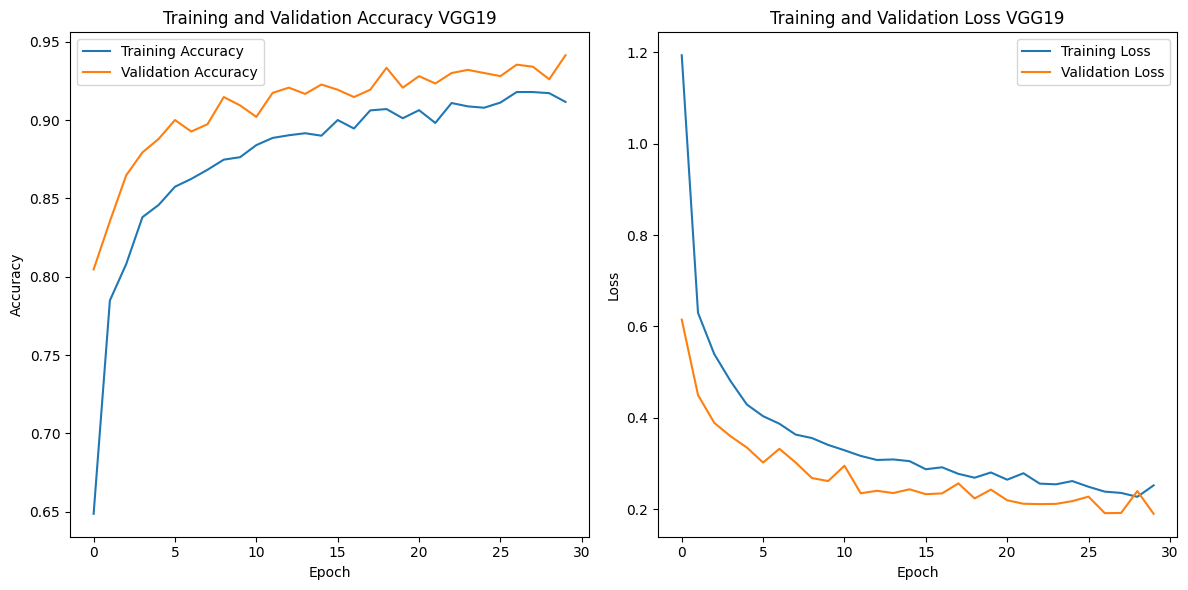

In [12]:
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_VGG19.history['accuracy'], label='Training Accuracy')
plt.plot(history_VGG19.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy VGG19')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_VGG19.history['loss'], label='Training Loss')
plt.plot(history_VGG19.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss VGG19')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
model_VGG19.save("model_VGG19.keras")

## ResNet152

In [14]:
tf.keras.backend.clear_session()

shape_ResNet152 = Input(shape=(224, 224, 3))
input_ResNet152 = prep_ResNet152(shape_ResNet152)

base_model_ResNet152 = ResNet152(
    weights='imagenet',
    include_top=False,
    input_tensor=input_ResNet152
)

base_model_ResNet152.trainable = False

x_ResNet152 = base_model_ResNet152.output
x_ResNet152 = GlobalAveragePooling2D()(x_ResNet152)
x_ResNet152 = Dense(512, activation='relu')(x_ResNet152)
x_ResNet152 = Dropout(0.5)(x_ResNet152)

output_ResNet152 = Dense(10, activation='softmax')(x_ResNet152)

model_ResNet152 = Model(inputs=base_model_ResNet152.input, outputs=output_ResNet152)

model_ResNet152.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ResNet152.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ add[0][0]         │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c

 Total params: 59,425,162 (226.69 MB)

 Trainable params: 1,054,218 (4.02 MB)

 Non-trainable params: 58,370,944 (222.67 MB)

## Train ResNet152

In [15]:
history_ResNet152 = model_ResNet152.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 540s 2s/step - accuracy: 0.7450 - loss: 0.7895 - val_accuracy: 0.8640 - val_loss: 0.4289
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - accuracy: 0.8431 - loss: 0.4467 - val_accuracy: 0.8853 - val_loss: 0.3137
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - accuracy: 0.8653 - loss: 0.3852 - val_accuracy: 0.9027 - val_loss: 0.2872
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 520s 2s/step - accuracy: 0.8816 - loss: 0.3292 - val_accuracy: 0.9220 - val_loss: 0.2407
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 520s 2s/step - accuracy: 0.8967 - loss: 0.2912 - val_accuracy: 0.9147 - val_loss: 0.2259
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 524s 2s/step - accuracy: 0.8989 - loss: 0.2824 - val_accuracy: 0.9187 - val_loss: 0.2287
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 524s 2s/step - accuracy: 0.9053 - loss: 0.2700 - val_accuracy: 0.9233 - val_loss: 0.2174
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - accuracy: 0.9011 - loss: 0.2712 - val_accu

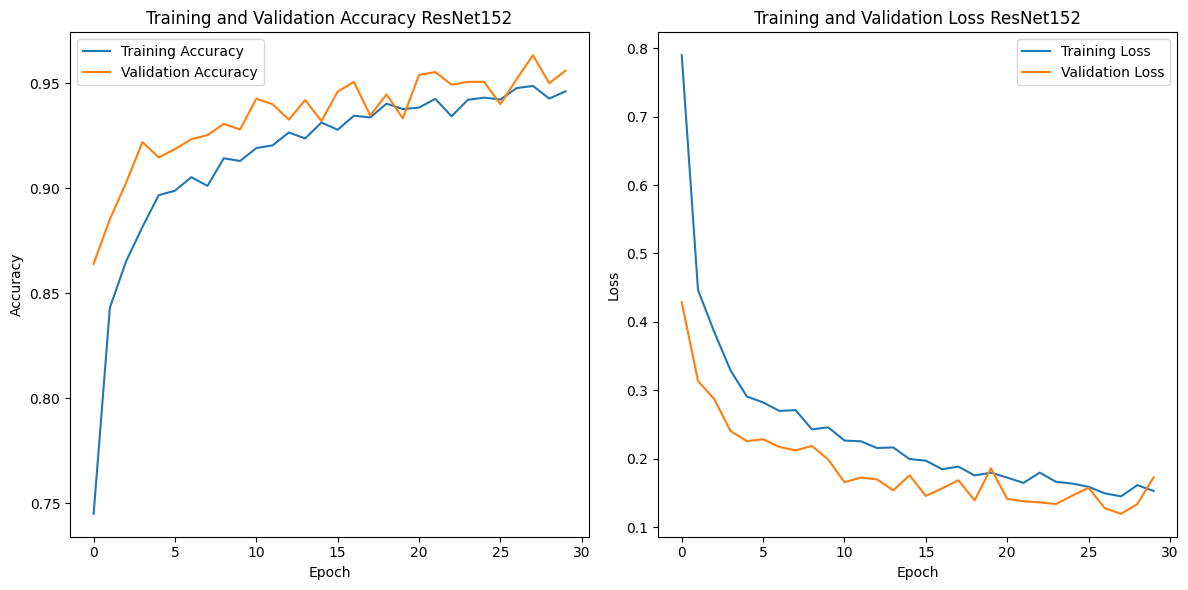

In [16]:
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_ResNet152.history['accuracy'], label='Training Accuracy')
plt.plot(history_ResNet152.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy ResNet152')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_ResNet152.history['loss'], label='Training Loss')
plt.plot(history_ResNet152.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss ResNet152')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
model_ResNet152.save("model_ResNet152.keras")

## MobileNetV2

In [9]:
tf.keras.backend.clear_session()

shape_MobileNetV2 = Input(shape=(224, 224, 3))
input_MobileNetV2 = prep_MobileNetV2(shape_MobileNetV2)

base_model_MobileNetV2 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_tensor=input_MobileNetV2
)

base_model_MobileNetV2.trainable = False

x_MobileNetV2 = base_model_MobileNetV2.output
x_MobileNetV2 = GlobalAveragePooling2D()(x_MobileNetV2)
x_MobileNetV2 = Dense(512, activation='relu')(x_MobileNetV2)
x_MobileNetV2 = Dropout(0.5)(x_MobileNetV2)

output_MobileNetV2 = Dense(10, activation='softmax')(x_MobileNetV2)

model_MobileNetV2 = Model(inputs=base_model_MobileNetV2.input, outputs=output_MobileNetV2)

model_MobileNetV2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_MobileNetV2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ subtract[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis

 Total params: 2,918,986 (11.14 MB)

 Trainable params: 661,002 (2.52 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train MobileNetV2

In [10]:
history_MobileNetV2 = model_MobileNetV2.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 162s 728ms/step - accuracy: 0.6944 - loss: 0.9142 - val_accuracy: 0.8260 - val_loss: 0.5006
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 157s 717ms/step - accuracy: 0.7996 - loss: 0.5737 - val_accuracy: 0.8733 - val_loss: 0.3899
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 154s 701ms/step - accuracy: 0.8299 - loss: 0.5017 - val_accuracy: 0.8733 - val_loss: 0.3669
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 157s 719ms/step - accuracy: 0.8410 - loss: 0.4448 - val_accuracy: 0.8793 - val_loss: 0.3341
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 158s 720ms/step - accuracy: 0.8516 - loss: 0.4201 - val_accuracy: 0.8827 - val_loss: 0.3200
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 199s 909ms/step - accuracy: 0.8610 - loss: 0.3920 - val_accuracy: 0.8767 - val_loss: 0.3529
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 165s 753ms/step - accuracy: 0.8670 - loss: 0.3759 - val_accuracy: 0.9013 - val_loss: 0.2835
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 157s 718ms/step - accuracy: 0.8724 -

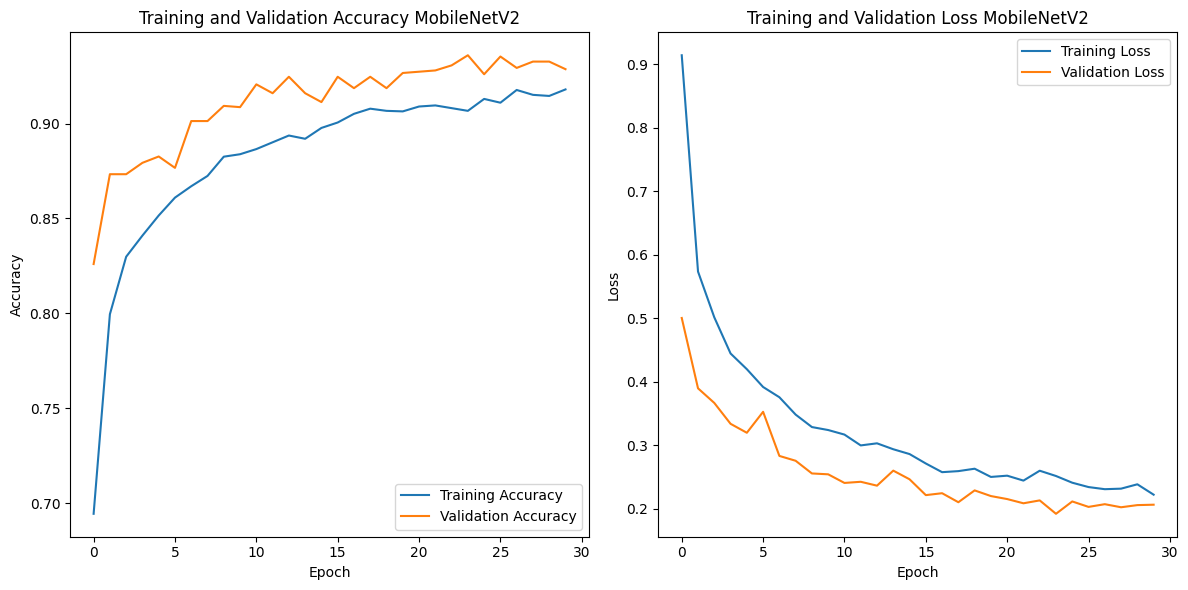

In [11]:
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_MobileNetV2.history['accuracy'], label='Training Accuracy')
plt.plot(history_MobileNetV2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy MobileNetV2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_MobileNetV2.history['loss'], label='Training Loss')
plt.plot(history_MobileNetV2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss MobileNetV2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
model_MobileNetV2.save("model_MobileNetV2.keras")

## DesneNet121

In [9]:
tf.keras.backend.clear_session()

shape_DenseNet121 = Input(shape=(224, 224, 3))
input_DenseNet121 = prep_DenseNet121(shape_DenseNet121)

base_model_DenseNet121 = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_tensor=input_DenseNet121
)

base_model_DenseNet121.trainable = False

x_DenseNet121 = base_model_DenseNet121.output
x_DenseNet121 = GlobalAveragePooling2D()(x_DenseNet121)
x_DenseNet121 = Dense(512, activation='relu')(x_DenseNet121)
x_DenseNet121 = Dropout(0.5)(x_DenseNet121)

output_DenseNet121 = Dense(10, activation='softmax')(x_DenseNet121)

model_DenseNet121 = Model(inputs=base_model_DenseNet121.input, outputs=output_DenseNet121)

model_DenseNet121.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_DenseNet121.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 224, 224,  │          0 │ add[0][0]         │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ true_divide_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],    

 Total params: 7,567,434 (28.87 MB)

 Trainable params: 529,930 (2.02 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## Train DenseNet121

In [10]:
history_DenseNet121 = model_DenseNet121.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.6957 - loss: 0.9190 - val_accuracy: 0.8413 - val_loss: 0.4729
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.8193 - loss: 0.5280 - val_accuracy: 0.8700 - val_loss: 0.3798
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 299s 1s/step - accuracy: 0.8411 - loss: 0.4474 - val_accuracy: 0.8507 - val_loss: 0.4791
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.8527 - loss: 0.4104 - val_accuracy: 0.8900 - val_loss: 0.3262
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.8633 - loss: 0.3777 - val_accuracy: 0.9027 - val_loss: 0.2691
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.8766 - loss: 0.3505 - val_accuracy: 0.8953 - val_loss: 0.2916
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.8850 - loss: 0.3163 - val_accuracy: 0.9033 - val_loss: 0.2705
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.8887 - loss: 0.3038 - val_accu

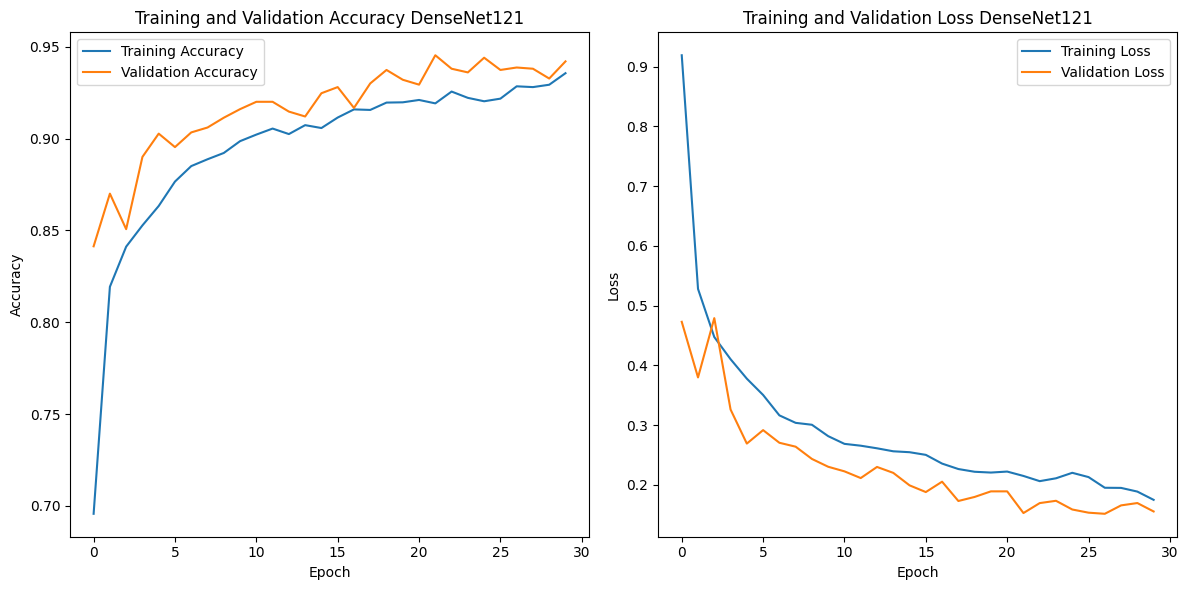

In [11]:
plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history_DenseNet121.history['accuracy'], label='Training Accuracy')
plt.plot(history_DenseNet121.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy DenseNet121')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_DenseNet121.history['loss'], label='Training Loss')
plt.plot(history_DenseNet121.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss DenseNet121')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
model_DenseNet121.save("model_DenseNet121.keras")

## Model Performance (Data Test)

In [14]:
ld_model_VGG19 = load_model("model_VGG19.keras", compile=False)
ld_model_ResNet152 = load_model("model_ResNet152.keras", compile=False)
ld_model_MobileNetV2 = load_model("model_MobileNetV2.keras", compile=False)
ld_model_DenseNet121 = load_model("model_DenseNet121.keras", compile=False)

In [19]:
models_DL = {
    "VGG19": ld_model_VGG19,
    "ResNet152": ld_model_ResNet152,
    "MobileNetV2": ld_model_MobileNetV2,
    "DenseNet121": ld_model_DenseNet121
}

y_true = test_data.classes

results = []

str_results = []

for name, model in models_DL.items():
    print(f"Evaluating {name}...")

    y_pred_prob = model.predict(test_data, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    results.append([name, acc, pre, rec, f1])
    str_results.append([f"{name}", f"{acc:.4f}", f"{pre:.4f}", f"{rec:.4f}", f"{f1:.4f}"])

df_results = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

df_results_str = pd.DataFrame(str_results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

print("\n=== HASIL PERBANDINGAN MODEL ===")
print(df_results_str.to_string(index=False))

Evaluating VGG19...
Evaluating ResNet152...
Evaluating MobileNetV2...
Evaluating DenseNet121...

=== HASIL PERBANDINGAN MODEL ===
      Model Accuracy Precision Recall F1 Score
      VGG19   0.9247    0.9256 0.9247   0.9246
  ResNet152   0.9553    0.9589 0.9553   0.9558
MobileNetV2   0.9353    0.9376 0.9353   0.9355
DenseNet121   0.9433    0.9459 0.9433   0.9439


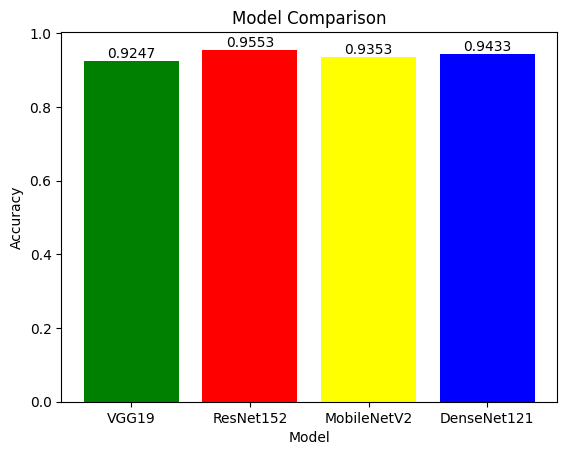

In [32]:
df_model = df_results["Model"]
df_accuracy = df_results["Accuracy"]

colors = ["green", "red", "yellow", "blue"]

plt.figure()
plt.bar(df_model, df_accuracy, color=colors)

for i, v in enumerate(df_accuracy):
    plt.text(i, v, f"{v:.4f}", ha='center', va='bottom')
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()


Menampilkan Confusion Matrix: VGG19


<Figure size 640x480 with 0 Axes>

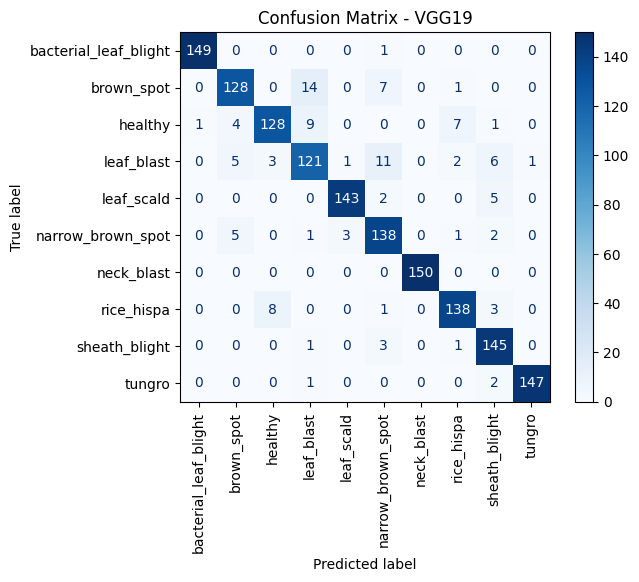


Menampilkan Confusion Matrix: ResNet152


<Figure size 640x480 with 0 Axes>

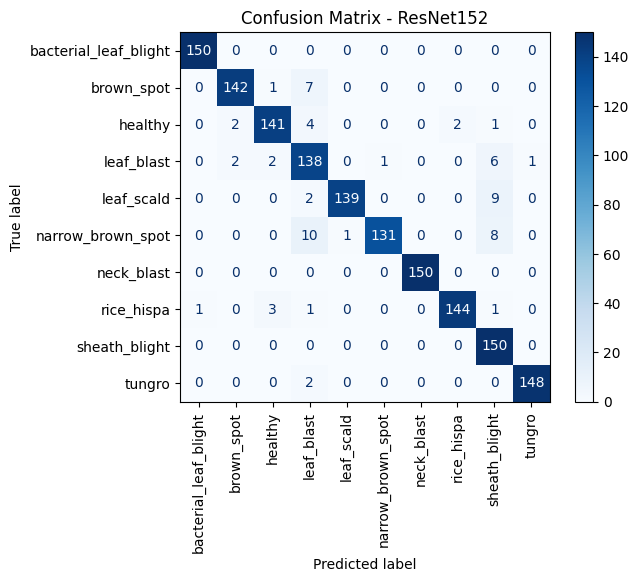


Menampilkan Confusion Matrix: MobileNetV2


<Figure size 640x480 with 0 Axes>

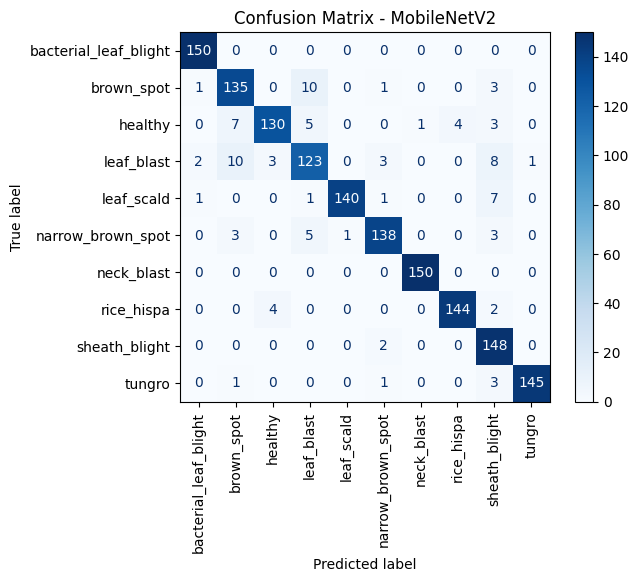


Menampilkan Confusion Matrix: DenseNet121


<Figure size 640x480 with 0 Axes>

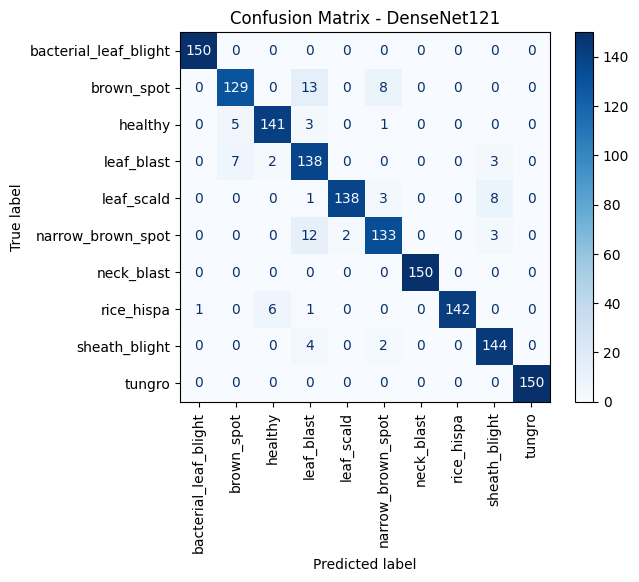

In [35]:

class_names = list(test_data.class_indices.keys())

for name, model in models_DL.items():
    print(f"\nMenampilkan Confusion Matrix: {name}")

    y_pred_prob_cm = model.predict(test_data, verbose=0)
    y_pred_cm = np.argmax(y_pred_prob_cm, axis=1)

    cm = confusion_matrix(y_true, y_pred_cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    plt.figure()
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xticks(rotation=90)
    plt.show()

In [36]:
for name, model in models_DL.items():
    print(f"\n=== Classification Report: {name} ===")

    y_pred_prob_cr = model.predict(test_data, verbose=0)
    y_pred_cr = np.argmax(y_pred_prob_cr, axis=1)

    report = classification_report(
        y_true,
        y_pred_cr,
        target_names=class_names,
        digits=4
    )

    print(report)


=== Classification Report: VGG19 ===
                       precision    recall  f1-score   support

bacterial_leaf_blight     0.9933    0.9933    0.9933       150
           brown_spot     0.9014    0.8533    0.8767       150
              healthy     0.9209    0.8533    0.8858       150
           leaf_blast     0.8231    0.8067    0.8148       150
           leaf_scald     0.9728    0.9533    0.9630       150
    narrow_brown_spot     0.8466    0.9200    0.8818       150
           neck_blast     1.0000    1.0000    1.0000       150
           rice_hispa     0.9200    0.9200    0.9200       150
        sheath_blight     0.8841    0.9667    0.9236       150
               tungro     0.9932    0.9800    0.9866       150

             accuracy                         0.9247      1500
            macro avg     0.9256    0.9247    0.9246      1500
         weighted avg     0.9256    0.9247    0.9246      1500


=== Classification Report: ResNet152 ===
                       precision   